In [1]:
import pandas as pd
df = pd.read_csv('final_with_sentiment.csv')

C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\kumar_santhosh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [5]:
def business_decision(row):
    segment = row['Segment']
    sentiment = row['Predicted_Sentiment']   # ✅ FIXED

    # HIGH VALUE
    if segment == "High Value Customers":
        if sentiment == "Positive":
            return "Loyalty Rewards", "Medium"
        else:
            return "Immediate Retention Offer", "High"

    # NEW CUSTOMERS
    elif segment == "New Customers":
        if sentiment == "Positive":
            return "Upsell / Cross-sell", "Medium"
        else:
            return "Onboarding Improvement", "High"

    # AT RISK
    elif segment == "At Risk Customers":
        if sentiment == "Positive":
            return "Engagement Campaign", "Medium"
        else:
            return "Win-back Campaign", "High"

    # BUDGET BUYERS
    elif segment == "Budget Buyers":
        if sentiment == "Positive":
            return "Discount Offers", "Low"
        else:
            return "Low Priority", "Low"

    return "Unknown", "Low"

In [4]:
df.head()

,Income,Recency,Customer_Days,Total_Spending,Total_Purchases,Cluster,Segment,Recommendation,Strategy,Channels,Offers,Goal,Customer_Review,Predicted_Sentiment
0,58138.0,58,4951,1617,25,3.0,Budget Buyers,"{'Strategy': 'Price-Based Promotions', 'Channe...",Price-Based Promotions,"SMS, Ads","Coupons, Seasonal Discounts",Increase purchase frequency,Delicious chili. Amazon has the best price. We...,Positive
1,46344.0,38,4401,27,6,1.0,New Customers,"{'Strategy': 'Welcome Campaign', 'Channels': [...",Welcome Campaign,"Email, SMS",First Purchase Discount,Convert into repeat customers,"We really love our Keurig, and the best place ...",Positive
2,71613.0,26,4600,776,21,2.0,At Risk Customers,"{'Strategy': 'Re-engagement Campaign', 'Channe...",Re-engagement Campaign,"Email, Push Notifications",Win-back Discounts,Prevent churn,Order Saturday arrived Monday. Product is grea...,Positive
3,26646.0,26,4427,53,8,1.0,New Customers,"{'Strategy': 'Welcome Campaign', 'Channels': [...",Welcome Campaign,"Email, SMS",First Purchase Discount,Convert into repeat customers,"I got this tea on impulse, having never tried ...",Positive
4,58293.0,94,4449,422,19,3.0,Budget Buyers,"{'Strategy': 'Price-Based Promotions', 'Channe...",Price-Based Promotions,"SMS, Ads","Coupons, Seasonal Discounts",Increase purchase frequency,It's a very good tasting tea if you like licor...,Positive


In [6]:
df[['Final_Action', 'Priority']] = df.apply(
    business_decision, axis=1, result_type='expand'
)

In [7]:
df['Final_Action'].value_counts()
df['Priority'].value_counts()

Priority
Medium    1451
Low        556
High       229
Name: count, dtype: int64

In [10]:
df.groupby(['Segment', 'Priority']).size()

Segment               Priority
At Risk Customers     High         76
                      Medium      417
Budget Buyers         Low         556
High Value Customers  High         64
                      Medium      478
New Customers         High         89
                      Medium      556
dtype: int64

<Axes: xlabel='Priority', ylabel='count'>

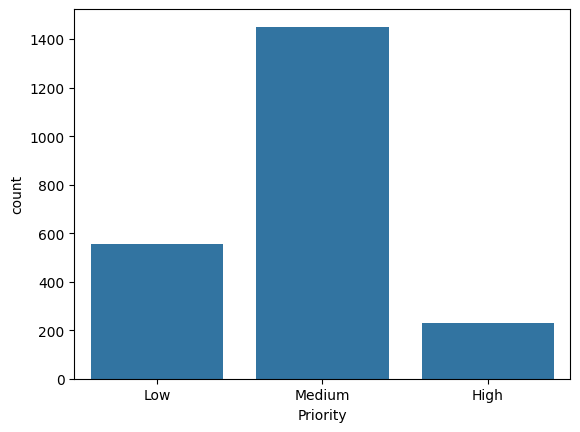

In [11]:
sns.countplot(data=df, x='Priority')

<Axes: xlabel='count', ylabel='Final_Action'>

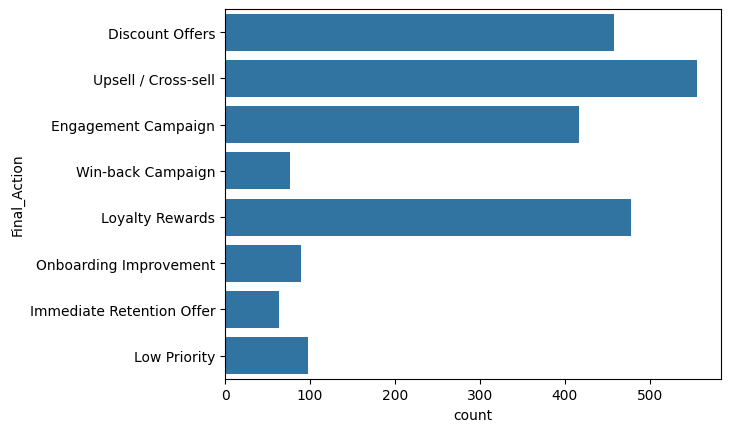

In [12]:
sns.countplot(data=df, y='Final_Action')

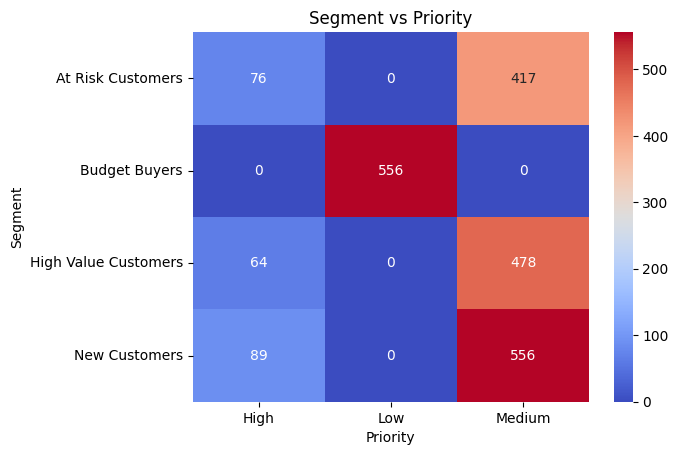

In [13]:
pivot = df.pivot_table(index='Segment', columns='Priority', aggfunc='size', fill_value=0)

sns.heatmap(pivot, annot=True, fmt='d', cmap='coolwarm')
plt.title("Segment vs Priority")
plt.show()